## Module 8 Class activities
This notebook is a starting point for the exercises and activities that we'll do in class. We'll parse some PDFs, and then implement some simple "bag of words" models.

Our running example: the [City of Palm Springs General Plan update](https://www.psgeneralplan.com).

Before you attempt any of these activities, make sure to watch the video lectures for this module.

### Reading and cleaning PDFs

Let's read in [this PDF of public comments](https://www.psgeneralplan.com/_files/ugd/89af76_0b8c3cd9a25140f4a9791570af8d6ba0.pdf). It's in the `data/` folder in your GitHub repository.

I suggest using `pdfminer` (as in Lecture 17), but you could try other PDF parsing libraries if you like. If you didn't install it already while watching the video lectures, you'll need to do that first.

<div class="alert alert-block alert-info">

<strong>Exercise:</strong> Read in the public comments to a string.
</div>

In [47]:
from pdfminer.high_level import extract_text

# your code here

fn = 'data/PS_VP_Survey_Results_FINAL.pdf'
text = extract_text(fn)
print('Text is {} characters long'.format(len(text)))

Text is 180290 characters long


<div class="alert alert-block alert-info">

<strong>Exercise:</strong> Inspect the string. Does it look usable? Write down what you think you'd need to do to clean it up. 
    
Explain your reasoning to your neighbor.

In [48]:
print(text[40000:40100])

ncreases with upscale developments.

3/11/2020 4:01 PM

How will you support Palm Springs as one of 


Write down your thoughts here.

You may have come up with better ideas (implement them!).

First, note that the first 9 pages are survey responses - not comments. The first "real" comment is "It doesn't speak about the people..."

You can exclude those in a couple of ways. We could have ignored the first 8 pages when loading in via `pdfminer`. Or we can search for the text, "It doesn't speak about the people," and remove all of the earlier part of the string as follows:
* `txt.find("It doesn't")` will give you the location of where that comment starts
* `txt = txt[txt.find("It doesn't"):]` will give you a new string that starts at that location.

Once we've done that, we can convert all tabs, newlines, and multiple spaces to a single space.

In [49]:
# Example
my_text = 'This is the part of the string I want to exclude. We can start here.'
print(my_text.find('We can start'))
print(my_text[my_text.find('We can start'):])

# this is the same
print(my_text[50:])

50
We can start here.
We can start here.


In [88]:
pc_text = text

In [89]:
pc_text.find("It doesn")
#"It doesn't"ではこの部分は検索できなかった。理由は、single quoteが別の形式だったから

6044

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Clean up the comments, by (i) removing the first 8 pages, (ii) removing the characters that are not letters or spaces, and (iii) replacing whitespace (e.g. newlines, tabs, and multiple spaces) with a single space.
</div>

In [90]:
pc_text = pc_text[pc_text.find("It doesn"):]

*Hints:*
* You'll need `regex`
* Start with the first comment - write a regex that will clean up the first element in your list
* Once you've figured that out, apply it to everything in your list with a loop or list comprehension. 

In [91]:
import re
# your code here 

In [92]:
#[^A-z\s] captures anything that is not a letter or whitespace
#retains the digits 0 through 9, too
pc_text_wordsonly = re.sub(r"[^A-z0-9\s]", "", pc_text)
# and remove duplicate spaces
pc_text_wordsonly = re.sub(r"\s+", " ", pc_text_wordsonly)

### Word counts
Now we have our cleaned up string. Let's look at a bag of words model - basically, what are the most frequent words. 

First, we need to split our string into a list of words, and remove the stopwords. Hint: Think about case too!

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a list of words, removing stopwords.</div>

In [97]:
# your code here
with open('scratch/pc_text_wordsonly.txt', 'w', encoding="utf-8") as f:
    f.write(txt)

In [98]:
with open('scratch/pc_text_wordsonly.txt','r') as f:
    pc_text_wordsonly = f.read()
print(len(pc_text_wordsonly))

174246


In [99]:
wordlist = pc_text_wordsonly.split()

wordlist

In the lecture video, we wrote our own custom word count function. But `nltk` actually has that built in. It does counts of individual words, but also of N-grams. For example, a bigram (N-gram of 2) could be "Palm Springs" or "affordable housing."

##### ポイント
splitではなくword_tokenizeを使う
indexが一致している事を確認（indexがwordになっているかどうか）
lower caseになっているか

In [101]:
# example
from nltk import ngrams, FreqDist
sample_words = ['a', 'list','of','words','some', 'repeat', 'and','repeat','themselves', 'repeat','themselves']
FreqDist(ngrams(sample_words, 1))

FreqDist({('repeat',): 3, ('themselves',): 2, ('a',): 1, ('list',): 1, ('of',): 1, ('words',): 1, ('some',): 1, ('and',): 1})

In [102]:
# example bigrams
FreqDist(ngrams(sample_words, 2))

FreqDist({('repeat', 'themselves'): 2, ('a', 'list'): 1, ('list', 'of'): 1, ('of', 'words'): 1, ('words', 'some'): 1, ('some', 'repeat'): 1, ('repeat', 'and'): 1, ('and', 'repeat'): 1, ('themselves', 'repeat'): 1})

<Axes: xlabel='Samples', ylabel='Counts'>

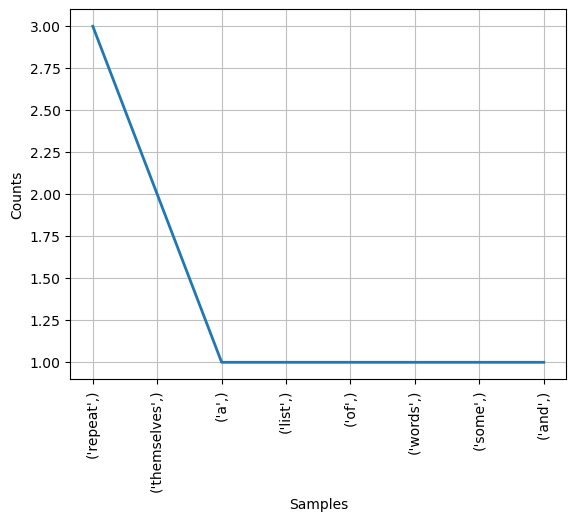

In [103]:
# we can also plot the frequencies
FreqDist(ngrams(sample_words, 1)).plot()

In [104]:
FreqDist(ngrams(wordlist, 1))

FreqDist({('the',): 870, ('to',): 820, ('and',): 711, ('PM',): 573, ('of',): 524, ('a',): 463, ('is',): 380, ('be',): 305, ('AM',): 299, ('that',): 287, ...})

In [105]:
# example bigrams
FreqDist(ngrams(wordlist, 2))

FreqDist({('Palm', 'Springs'): 164, ('to', 'be'): 136, ('of', 'the'): 94, ('needs', 'to'): 92, ('PM', '3/4/2020'): 86, ('need', 'to'): 81, ('should', 'be'): 78, ('in', 'the'): 66, ('this', 'priority'): 60, ('/', '70'): 55, ...})

<Axes: xlabel='Samples', ylabel='Counts'>

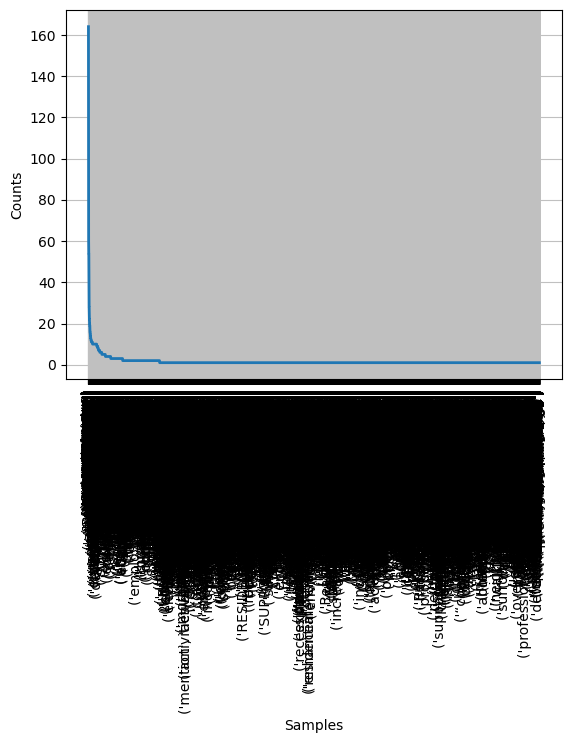

In [106]:
# we can also plot the frequencies
FreqDist(ngrams(wordlist, 2)).plot()

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Plot the frequencies of words (and bigrams) in your own wordlist. Experiment with the plot arguments, and what you can do with the object returned by <strong>FreqDist</strong>. Based on your results, you might want to add more words to your list of stopwords.</div>

In [ ]:
# your code here

## Extensions to bags of words
One potential use of these "bags of words" models is to look at differences across space or across time. For example, do building or land use permits change over time - when does "add garage" become less common, and "add ADU" more common. 

Or we could look at how word frequency changes across space or cities.

Let's try this with the San Francisco Board of Supervisors meetings. [This webpage](http://sanfrancisco.granicus.com/ViewPublisher.php?view_id=10) gives the archived transcripts ("caption notes").

You could scrape all of the URLs (that's a good exercise!), but for now, just manually create a list with a half dozen or so of the caption notes.

Write a function that for a given URL:
* Gets the text (use `requests`)
* Cleans the text
* Gets the word counts

Then, think about how you might chart the results over time.

This is an open-ended prompt, so spend some time thinking through the steps conceptually, even if you don't get far in implementing it. For example, how will you organize the text of each documents and the counts? In a list? A dataframe? Will you loop through each URL?

In [ ]:
# your code here

<div class="alert alert-block alert-info">
<h3>You should now be able to:</h3>
<ul>
  <li>Read a PDF into a Python string</li>
  <li>Clean the string</li>
  <li>Count words and n-grams, and plot the results</li>
</ul>
</div>